In [4]:
import arviz as az
import numpy as np
from scipy.stats import wishart

# Set random seed for reproducibility (same seed of Mattia's 250D notebook)
rng = np.random.default_rng(12345)

In [5]:
# body of the foor loop in the algorithm 3
def NUTS_one_step(L: Callable,
                  theta_0: jnp.ndarray,
                  epsilon: float,
                  key: jnp.ndarray,
                  j_max: int = 10):

    # 1. Sample momentum
    key, sub_r = jrnd.split(key)
    r_0 = jrnd.normal(sub_r, shape=theta_0.shape)

    # 2. Slice variable
    log_joint_0 = log_p(L, theta_0, r_0)
    key, sub_u = jrnd.split(key)
    u = jnp.exp(log_joint_0) * jrnd.uniform(sub_u)

    # 3. Initialize tree
    theta_minus = theta_0
    theta_plus  = theta_0
    r_minus     = r_0
    r_plus      = r_0
    theta_prime = theta_0
    n_prime     = jnp.array(1, dtype=jnp.int32)
    s_prime     = jnp.array(1, dtype=jnp.int32)
    alpha_sum   = jnp.array(0.0)
    n_alpha     = jnp.array(0, dtype=jnp.int32)

    # depth of the tree
    j = 0 

    # 4. Doubling
    while (s_prime == 1) & (j < j_max):

        # Choose a direction
        key, sub_v = jrnd.split(key)
        v_j = jnp.where(jrnd.uniform(sub_v) < 0.5, -1, 1)

        if v_j == -1:
            root = Root(theta_minus, r_minus, u, v_j, j, epsilon, theta_0, r_0)
        else:
            root = Root(theta_plus,  r_plus,  u, v_j, j, epsilon, theta_0, r_0)

        # Call the BuildTree function
        tree, key = BuildTree(L, root, key)

        if v_j == -1:
            theta_minus, r_minus = tree.theta_minus, tree.r_minus
        else:
            theta_plus,  r_plus  = tree.theta_plus,  tree.r_plus

        key, sub = jrnd.split(key)
        total_n = n_prime + tree.n_prime
        p = jnp.where(total_n > 0, tree.n_prime / total_n, 0.5)
        choose = jrnd.bernoulli(sub, p)
        theta_prime = jnp.where(choose, tree.theta_prime, theta_prime)

        n_prime   = n_prime + tree.n_prime
        s_prime   = s_prime * tree.s_prime * stop_criterion(
            theta_minus, theta_plus, r_minus, r_plus
        )
        alpha_sum = alpha_sum + tree.alpha_prime
        n_alpha   = n_alpha + tree.n_a_prime

        j += 1

    accept_rate = alpha_sum / jnp.maximum(1, n_alpha)
    return theta_prime, accept_rate, key


In [6]:
def NUTS_sampler(L: Callable,
                 theta_init: jnp.ndarray,
                 n_samples: int,
                 key: jnp.ndarray,
                 j_max: int = 10):

    epsilon = float(FindReasonableEpsilon(L, theta_init, key))

    thetas = []
    accs = []

    theta = theta_init

    for i in range(n_samples):
        theta, acc, key = NUTS_one_step(L, theta, epsilon, key, j_max=j_max)
        thetas.append(np.array(theta))
        accs.append(float(acc))

    return np.stack(thetas), np.array(accs), epsilon


In [7]:
# Define the pseudo log-potential
# Gaussian log-density
D = 10
df = D
A = wishart.rvs(df=df, scale=np.eye(D), random_state=rng).astype(np.float64)

@jax.jit
def L(theta: jnp.ndarray, precision_mat = A) -> jnp.float32:
    assert theta.ndim == 1
    return -0.5 * jnp.vdot(theta, precision_mat @ theta) 

In [8]:
dim = D
theta0 = jnp.zeros(dim)
key = jrnd.PRNGKey(0)

samples, accs, eps = NUTS_sampler(L, theta0, n_samples=1000, key=key)

print("epsilon:", eps)
print("mean:", samples.mean(axis=0))
theta_mean = samples.mean(axis=0)
print("cov:\n", np.cov(samples.T))
cov_mat = np.cov(samples.T)
print("mean accept rate:", accs.mean())

epsilon: 0.125
mean: [-0.42082012  0.06160907  0.06352825  0.30412638  0.45419854  0.68885463
 -0.7916458   0.06970405 -0.13829046  0.30213955]
cov:
 [[ 26.87608175   2.78884455  -5.07208548  -2.95279542 -11.76361389
  -22.67854438  18.26065163  -3.84394812  -2.29993898 -14.05602926]
 [  2.78884455   2.25572361   1.03672228   2.18987154   0.8676179
    2.21614319  -4.03682744   2.20237389  -3.77251144  -1.33989794]
 [ -5.07208548   1.03672228   3.50882063   2.04679922   2.85974004
    7.72439471  -6.84916439   4.53993168  -3.0061547    1.50457915]
 [ -2.95279542   2.18987154   2.04679922   4.48551914   5.13846271
    9.26250329 -11.28406386   3.30768992  -4.35678485   2.13725629]
 [-11.76361389   0.8676179    2.85974004   5.13846271   9.1812513
   16.02717041 -16.78603158   3.32840985  -2.64462425   7.31975919]
 [-22.67854438   2.21614319   7.72439471   9.26250329  16.02717041
   31.48014362 -31.31651766   9.68496194  -6.96736594  11.96215175]
 [ 18.26065163  -4.03682744  -6.84916439 -

/home/mattia/anaconda3/envs/alice/lib/python3.13/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n5'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='theta\n6'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n7'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>,
        <Axes: xlabel='t

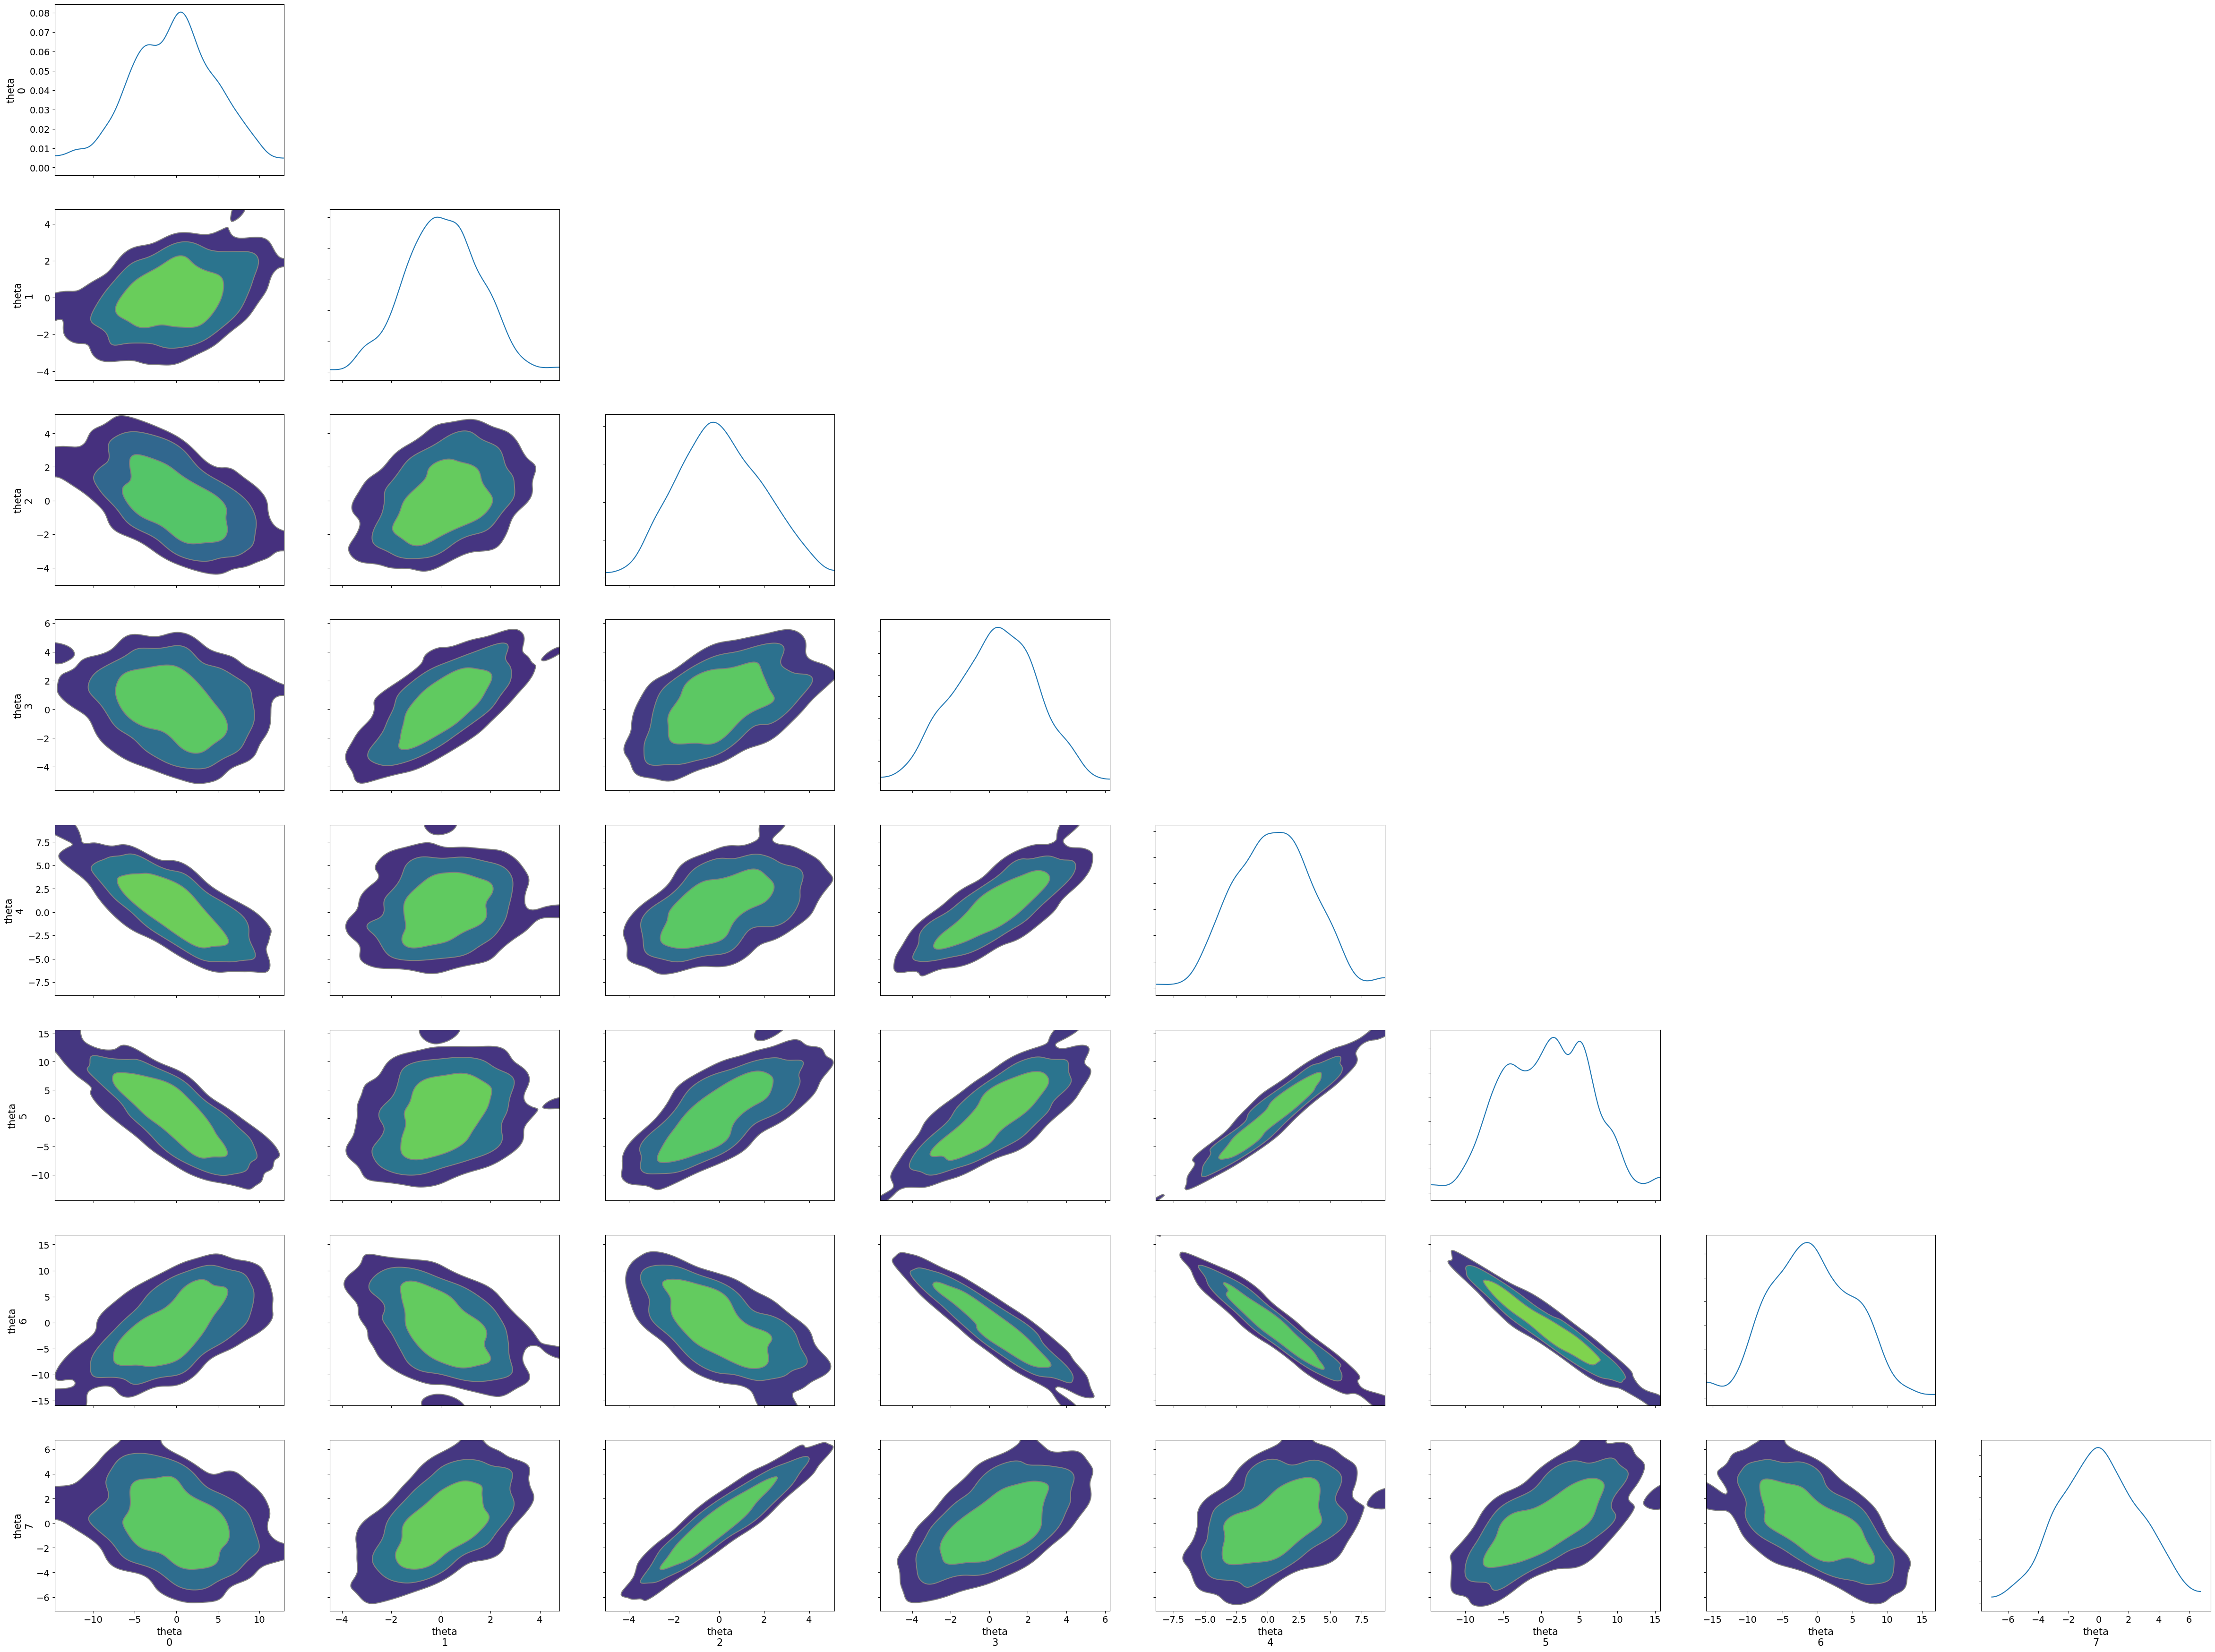

In [9]:
data_sample = samples[None, :, :]  

idata = az.from_dict(
    posterior={"theta": data_sample},
    coords={"theta_dim": np.arange(data_sample.shape[2])},
    dims={"theta": ["chain", "draw", "theta_dim"]},
)

az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)

In [10]:
var_k = [ cov_mat[i,i] for i in range(D) ]
var_k

[np.float64(26.876081752439415),
 np.float64(2.255723613594367),
 np.float64(3.5088206265949333),
 np.float64(4.485519140542597),
 np.float64(9.18125129736559),
 np.float64(31.48014362419375),
 np.float64(34.18278601891719),
 np.float64(6.877795765780053),
 np.float64(7.359943775079216),
 np.float64(9.276009342631653)]

In [11]:
theta_mean

array([-0.42082012,  0.06160907,  0.06352825,  0.30412638,  0.45419854,
        0.68885463, -0.7916458 ,  0.06970405, -0.13829046,  0.30213955],
      dtype=float32)

In [12]:
import matplotlib.pyplot as plt

In [13]:
# The theorical variance of each variable comes from inverting the precision matrix A
th_cov_mat = np.linalg.inv(A)
th_var_k = [ th_cov_mat[i,i] for i in range(D) ]
th_var_k

[np.float64(17.781220345391976),
 np.float64(1.9501961907725307),
 np.float64(2.5902294511420303),
 np.float64(4.015257292735635),
 np.float64(7.262011257769527),
 np.float64(23.04232321265636),
 np.float64(27.67829581962921),
 np.float64(5.0749694070982105),
 np.float64(5.946110118780801),
 np.float64(6.420260710626618)]

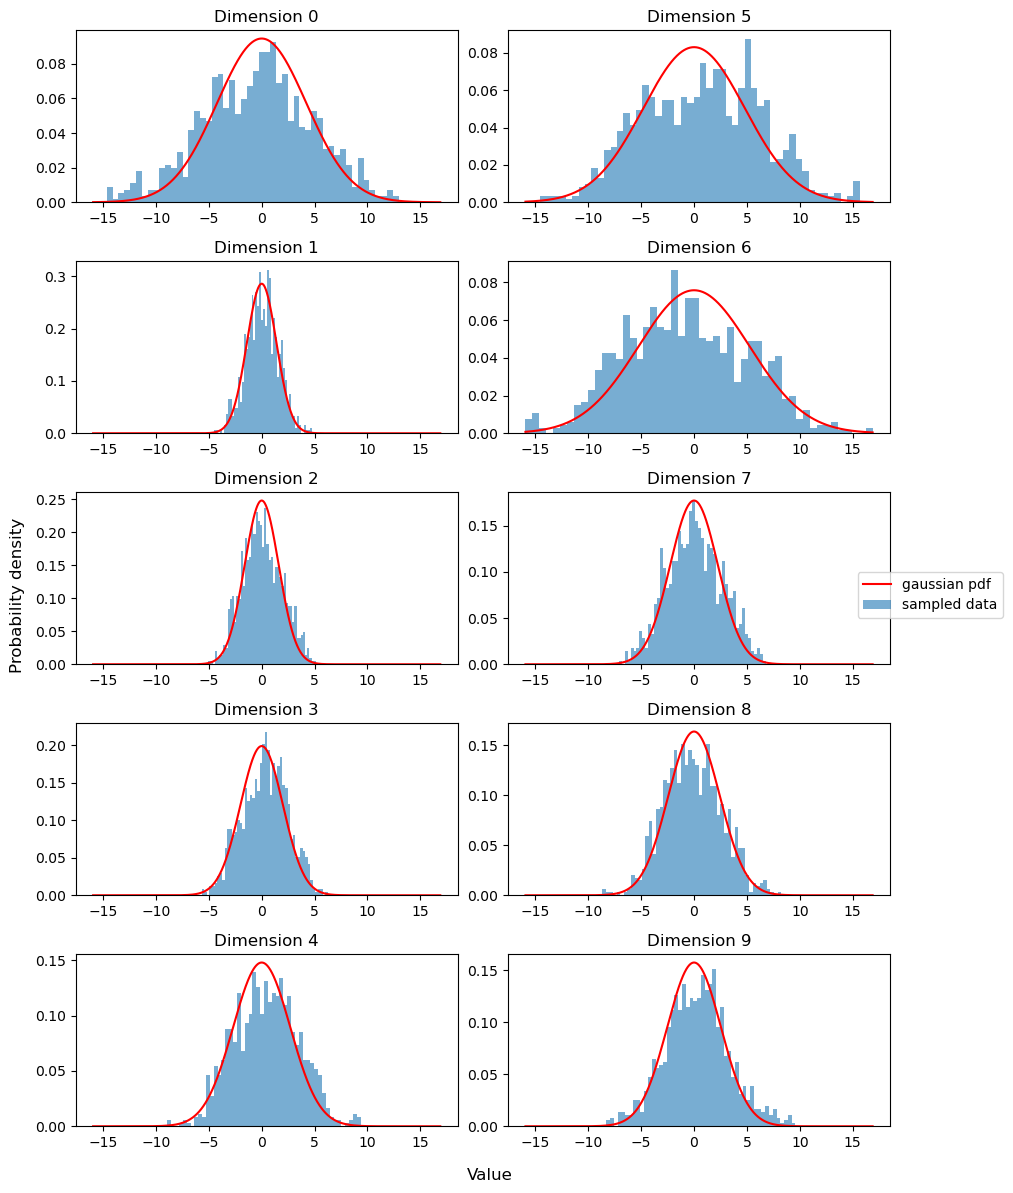

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import math

x = np.linspace(samples.min(), samples.max(), 1000)

fig, axs = plt.subplots(5, 2, figsize=(10, 12))

for j in range(2):        # colonne
    for i in range(5):    # righe
        
        k = i + 5*j       # indice globale della variabile (0..9)

        var = th_var_k[k]
        norm_factor = 1 / math.sqrt(2 * np.pi * var)
        pdf = norm_factor * np.exp(-(x**2) / (2 * var))

        axs[i, j].plot(x, pdf, color='red', label='gaussian pdf')
        axs[i, j].hist(samples.T[k], bins=50, density=True, alpha=0.6, label='sampled data')

        axs[i, j].set_title(f"Dimension {k}")

# --- LEGENDA UNICA ---
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5))

# --- ETICHETTE GLOBALI ---
fig.supxlabel("Value")
fig.supylabel("Probability density")

plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()
